In [1]:
import jax.numpy as jnp
import jax
import numpy as np

from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
jax.default_backend()

'gpu'

In [3]:
np.random.seed(1)

In [4]:
def generate_gaussian_feature_matrix(n, k, theta):
    return (1 / np.sqrt(n+theta)) * jnp.asarray(np.random.randn(k, n))

In [5]:
def data_generator(xi, gamma, m, n, theta, delta):
    A = jnp.asarray(np.random.randn(m,n))
    c = jnp.asarray(np.random.randn(m,1))
    X = np.sqrt(theta)*c*gamma.reshape(1,n) + A
    epsilon = jnp.asarray(np.random.randn(m,1))
    alpha = (xi.T @ gamma).item()
    y = jnp.maximum((1/np.sqrt(1+theta*(alpha**2))) * X @ xi,0) + delta * epsilon
    return X,y

In [6]:
def loss(w, y, b, RF, l, lambd):
    return jnp.mean(l(y, RF.T@w + b)) +lambd * (jnp.linalg.norm(w) ** 2)

In [7]:
def l(y, z):
    return ((y-z)**2)

In [8]:
def least_square_estimator(y, b, RF, lambd):
    k, m = RF.shape
    w = jnp.linalg.inv(RF @ RF.T + lambd * m * jnp.eye(k)) @ RF @ (y - b)
    return w

In [9]:
def ReLU(z):
    return jnp.maximum(z,0)

def tanh(z):
    return jnp.tanh(z)

In [10]:
rho = 1
n = 400
m = 500
m_new = 5000
lambd = 1e-2
delta = 0
theta = np.sqrt(n)
NB_TRIALS = 50

In [11]:
xi = np.random.randn(n, 1)
xi *= rho / np.linalg.norm(xi)
gamma = np.random.randn(n, 1)
gamma *= rho / np.linalg.norm(gamma)

In [12]:
z = np.random.randn(1000000)
rmu0 = ReLU(z).mean()
rmu1 = (z * ReLU(z)).mean()
rmus = np.sqrt((ReLU(z) ** 2).mean() - (rmu0**2) - (rmu1**2))
tmu0 = tanh(z).mean()
tmu1 = (z * tanh(z)).mean()
tmus = np.sqrt((tanh(z) ** 2).mean() - (tmu0**2) - (tmu1**2))

In [13]:
import gc,sys

def clear_caches():
    for module_name, module in sys.modules.items():
        if module_name.startswith("jax"):
            if module_name not in ["jax.interpreters.partial_eval"]:
                for obj_name in dir(module):
                    obj = getattr(module, obj_name)
                    if hasattr(obj, "cache_clear"):
                        try:
                            obj.cache_clear()
                        except:
                            pass
    gc.collect()

In [14]:
r_vals = [0.01, 0.1, 0.3, 0.4, 0.5, 0.7, 0.9, 1, 1.1, 1.5, 2, 3, 4, 5, 10]

relu_l_feature = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
relu_l_gaussian = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_gaussian = np.zeros((len(r_vals), NB_TRIALS))

tanh_l_feature = np.zeros((len(r_vals), NB_TRIALS))
tanh_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
tanh_l_gaussian = np.zeros((len(r_vals), NB_TRIALS))
tanh_gl_gaussian = np.zeros((len(r_vals), NB_TRIALS))


def RFM(
    F,
    data,
    data_new,
    m,
    activation,
    mu0,
    mu1,
    mu2,
    lambd=lambd,
    include_gaussian=False,
):
    X, y = data
    X_new, y_new = data_new

    RF_feature = activation(F @ X.T)
    RF_feature_new = activation(F @ X_new.T)
    w_feature = least_square_estimator(y, 0, RF_feature, lambd)
    l_feature_ = loss(w_feature, y, 0, RF_feature, l, lambd)
    gl_feature_ = loss(w_feature, y_new, 0, RF_feature_new, l, 0)

    if include_gaussian:
        z = jnp.asarray(np.random.randn(k, m))
        z_new = jnp.asarray(np.random.randn(k, 5 * m))
        RF_gaussian = mu0 + mu1 * F @ X.T + mu2* z
        RF_gaussian_new = mu0 + mu1 * F @ X_new.T + mu2 * z_new
        w_gaussian = least_square_estimator(y, 0, RF_gaussian, lambd)
        l_gaussian_ = loss(w_gaussian, y, 0, RF_gaussian, l, lambd)
        gl_gaussian_ = loss(w_gaussian, y_new, 0, RF_gaussian_new, l, 0)

        return (
            l_feature_.item(),
            gl_feature_.item(),
            l_gaussian_.item(),
            gl_gaussian_.item(),
        )
    else:
        return (l_feature_.item(), gl_feature_.item())


for e in tqdm(range(NB_TRIALS)):
    for r_i, r in enumerate(tqdm(r_vals)):
        k = int(m * r)
        F = generate_gaussian_feature_matrix(n, k, theta)
        data = data_generator(xi, gamma, m, n, theta, delta)
        data_new = data_generator(xi, gamma, 5 * m, n, theta, delta)

        (
            relu_l_feature[r_i, e],
            relu_gl_feature[r_i, e],
            relu_l_gaussian[r_i, e],
            relu_gl_gaussian[r_i, e],
        ) = RFM(
            F,
            data,
            data_new,
            m,
            ReLU,
            rmu0,
            rmu1,
            rmus,
            lambd=lambd,
            include_gaussian=True,
        )
        (
            tanh_l_feature[r_i, e],
            tanh_gl_feature[r_i, e],
            tanh_l_gaussian[r_i, e],
            tanh_gl_gaussian[r_i, e],
        ) = RFM(
            F,
            data,
            data_new,
            m,
            tanh,
            tmu0,
            tmu1,
            tmus,
            lambd=lambd,
            include_gaussian=True,
        )

        clear_caches()

In [17]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)

plt.style.use(["science", "bright"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times"],
        "font.size": 10,
        "figure.dpi": "600",
    }
)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

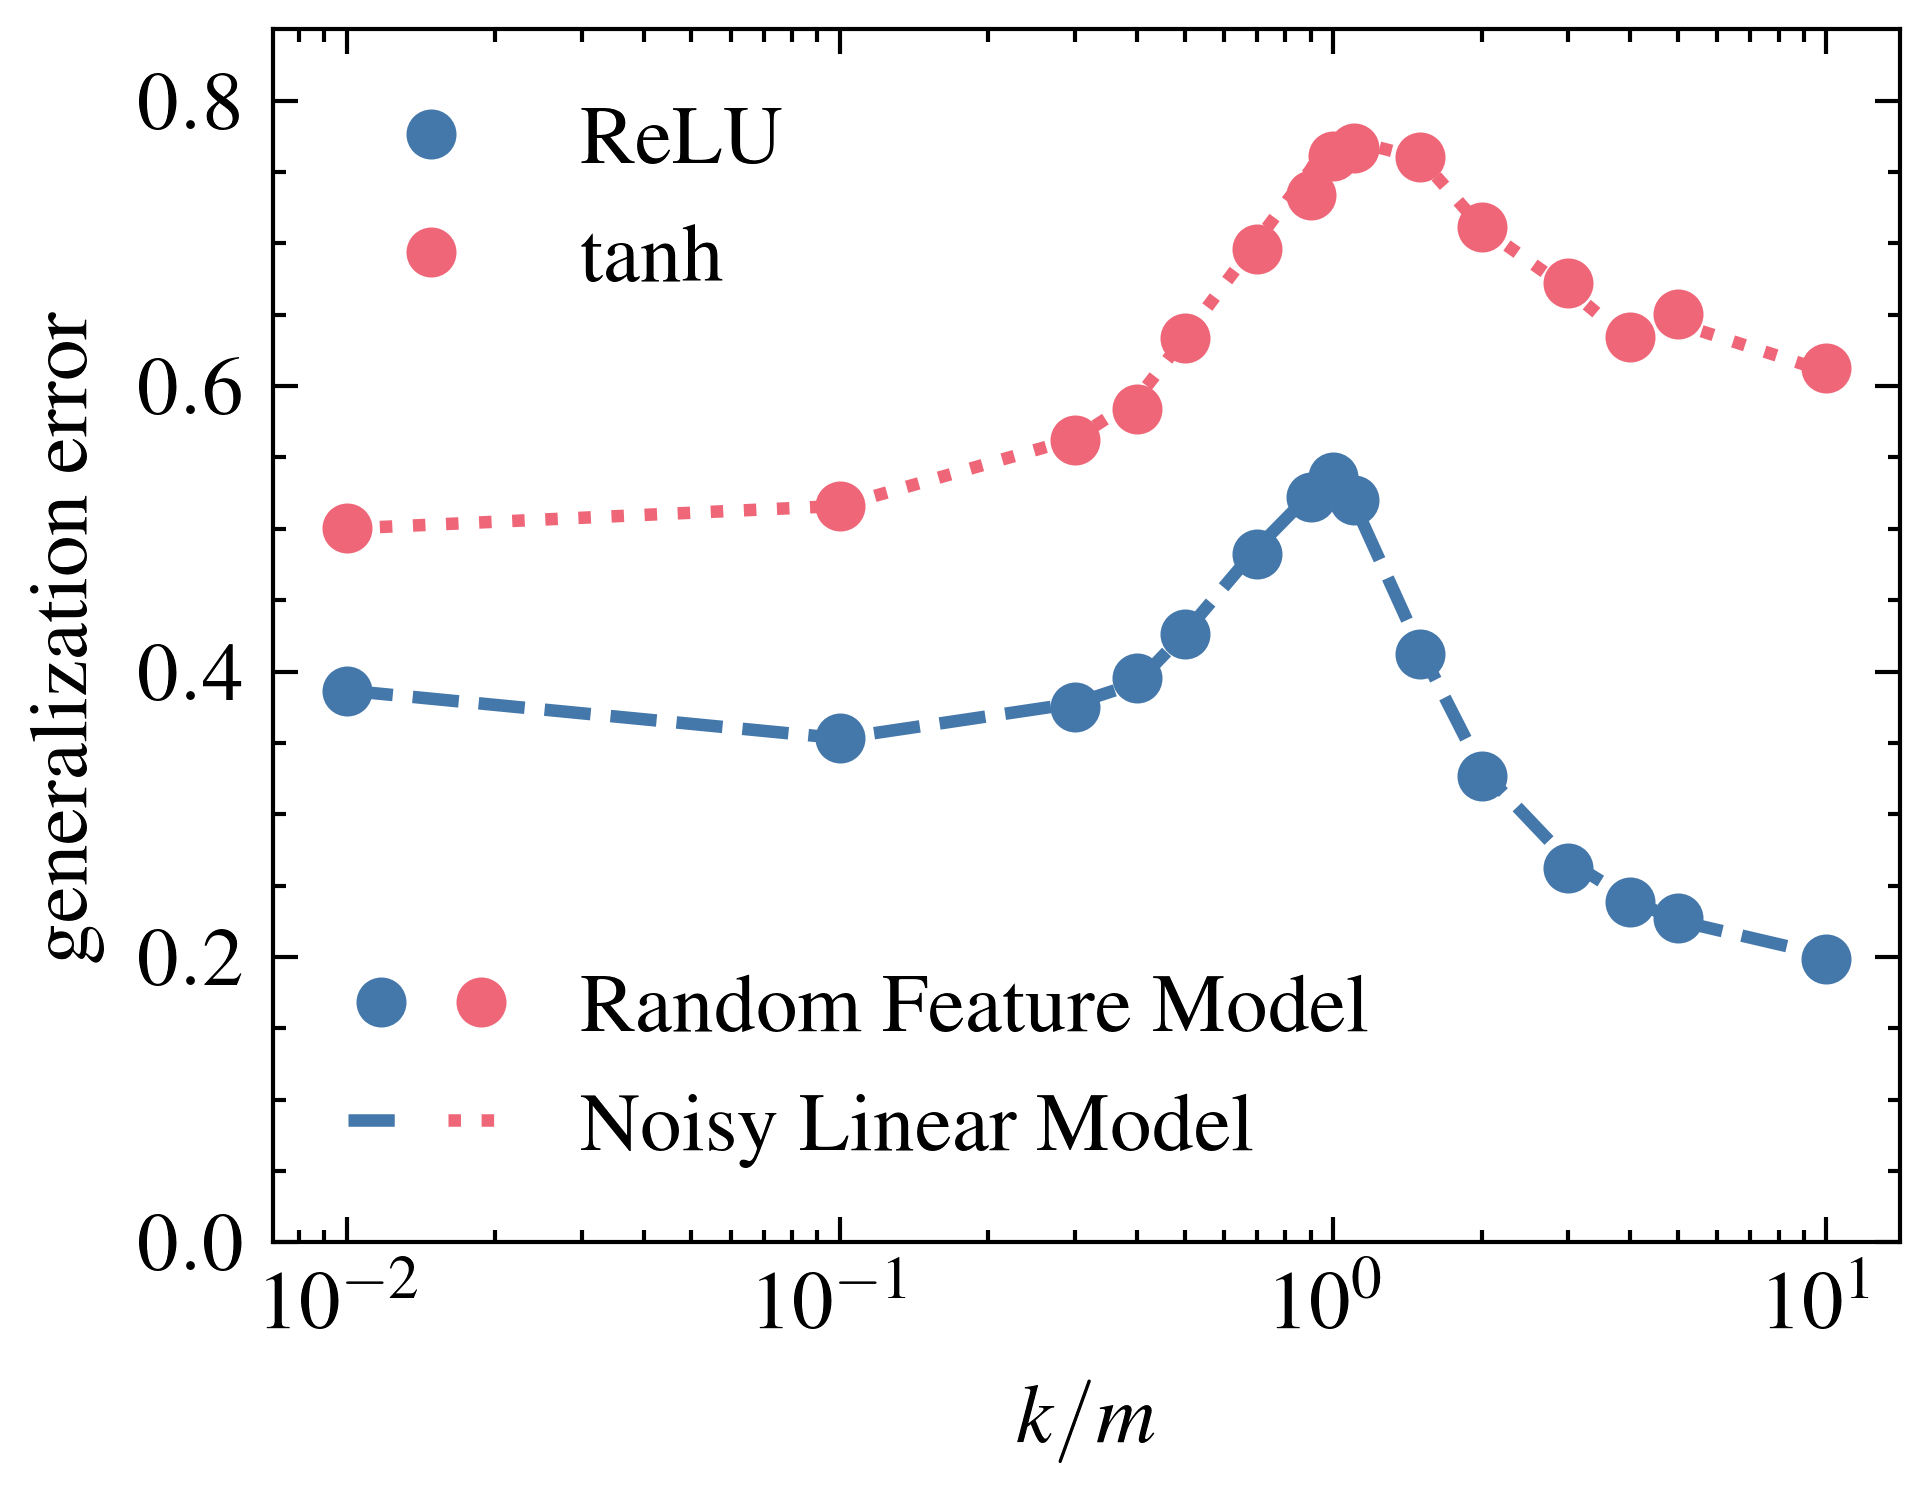

In [22]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature_gen,) = plt.plot(
    r_vals,
    np.mean(relu_gl_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(relu_gl_gaussian, axis=1),
    color=colors[0],
    linestyle="dashed",
    linewidth=1.5,
    label="ReLU",
)

(tanh_feature_gen,) = plt.plot(
    r_vals,
    np.mean(tanh_gl_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(tanh_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(tanh_gl_gaussian, axis=1),
    color=colors[1],
    linestyle="dotted",
    linewidth=1.5,
    label="tanh",
)
plt.xlabel(r"$k/m$")
plt.ylabel(r"generalization error")
plt.xscale("log")
plt.ylim(0, 0.85)

legend1 = plt.legend(
    [(relu_feature_gen), (tanh_feature_gen)],
    ["ReLU", "tanh"],
    loc=2,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
legend2 = plt.legend(
    [
        (relu_feature_gen, tanh_feature_gen),
        (relu_gaussian_gen, tanh_gaussian_gen),
    ],
    [
        "Random Feature Model",
        "Noisy Linear Model",
    ],
    loc=3,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
plt.gca().add_artist(legend1)

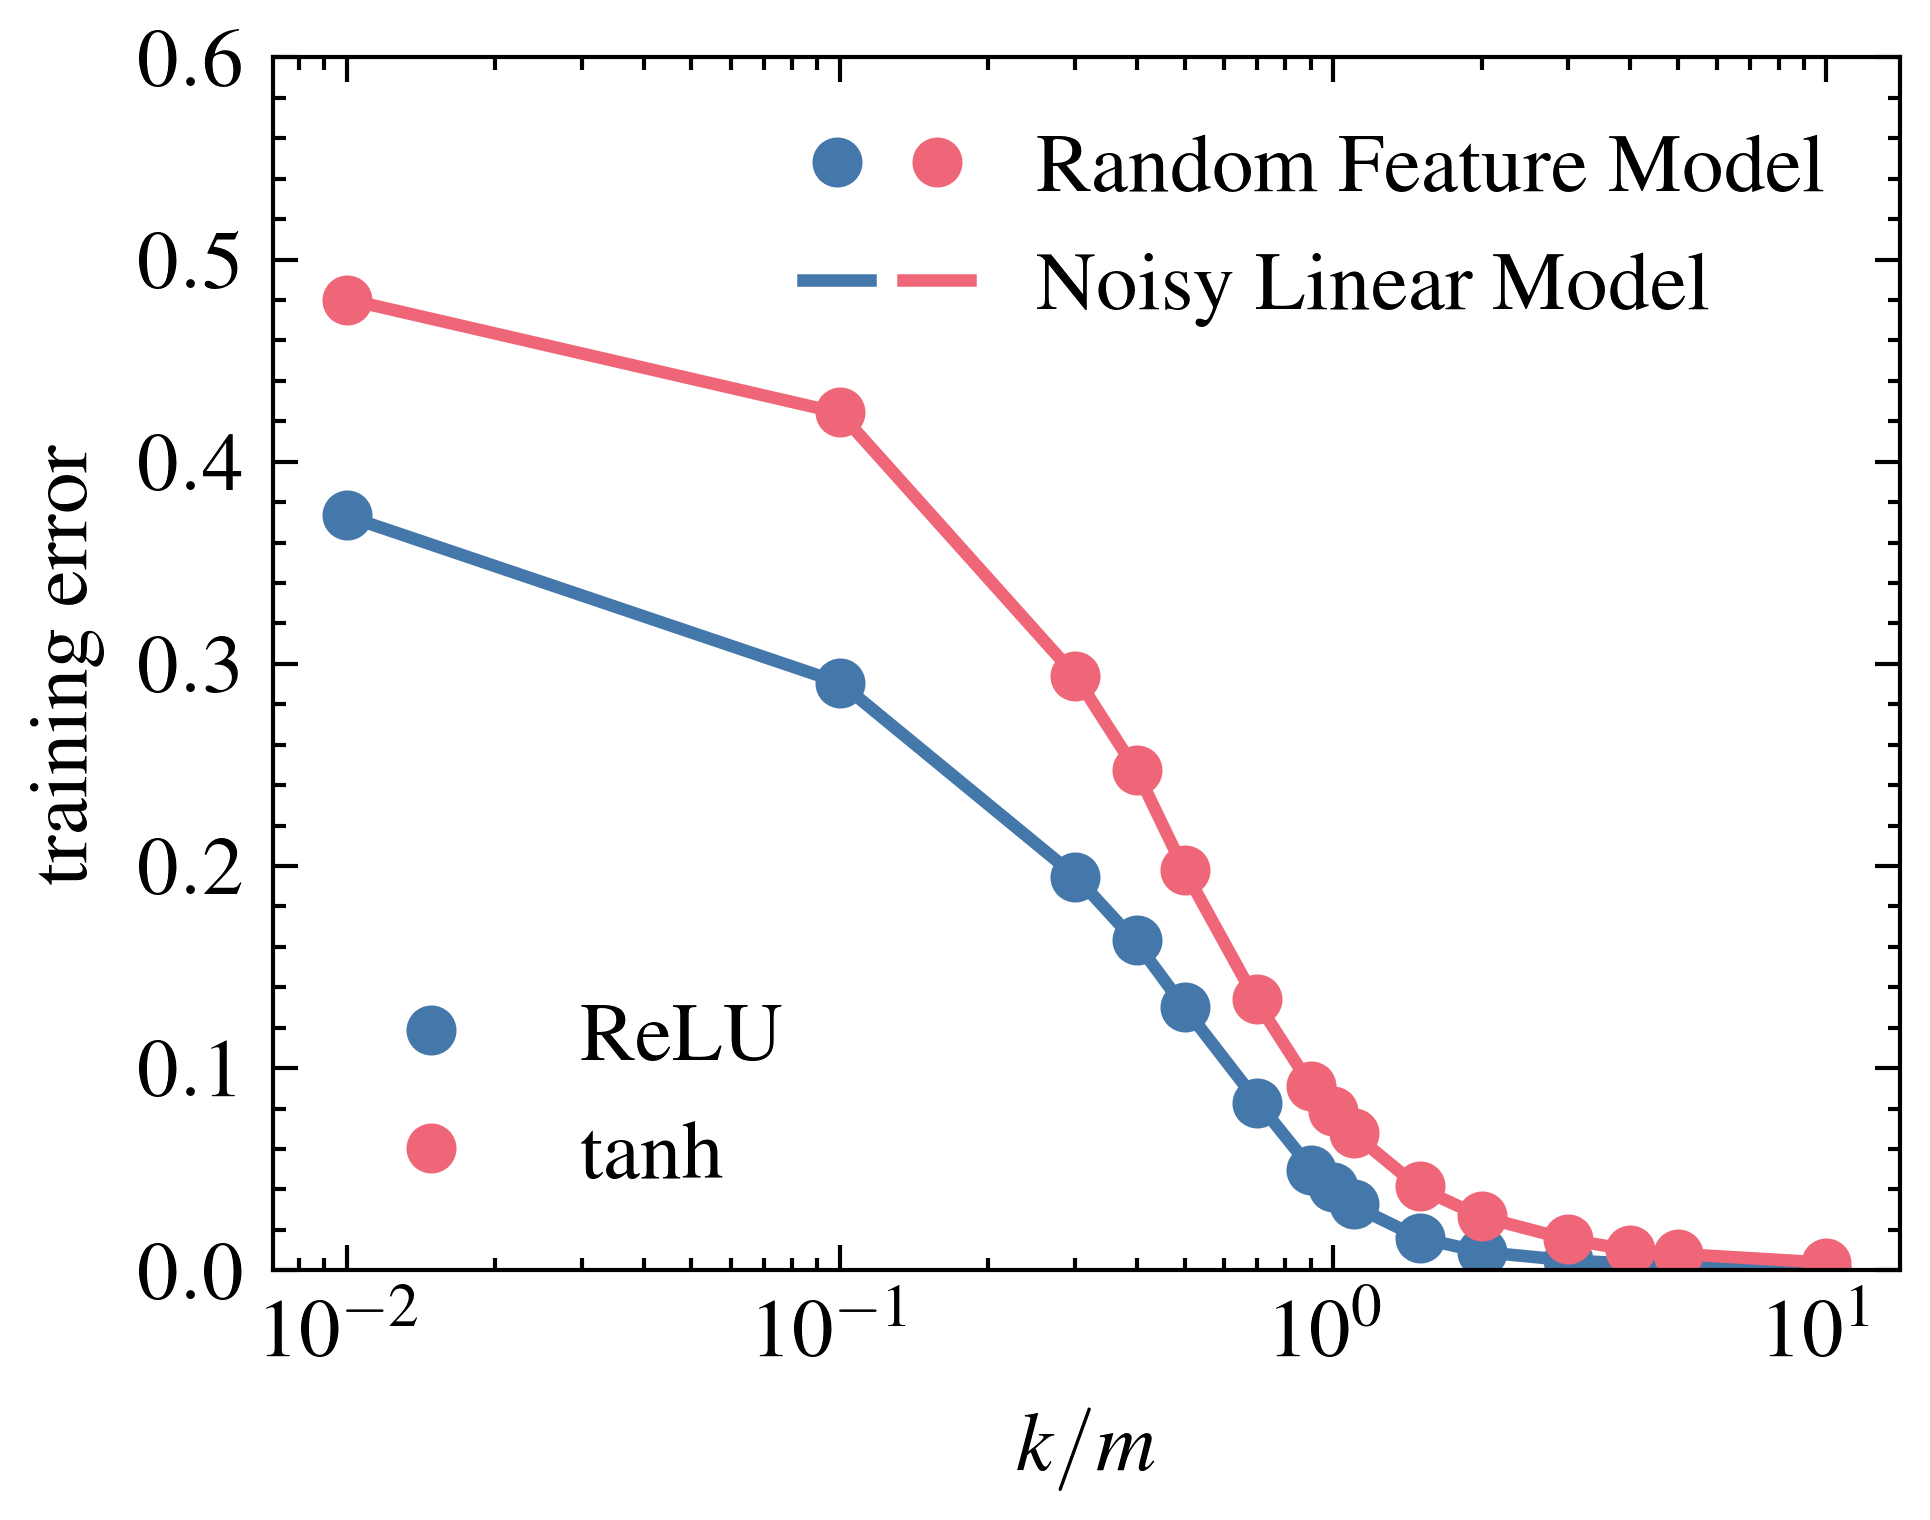

In [20]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature,) = plt.plot(
    r_vals,
    np.mean(relu_l_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian,) = plt.plot(
    r_vals,
    np.mean(relu_l_gaussian, axis=1),
    color=colors[0],
    linewidth=1.5,
    linestyle="solid",
)

(tanh_feature,) = plt.plot(
    r_vals,
    np.mean(tanh_l_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(tanh_gaussian,) = plt.plot(
    r_vals,
    np.mean(tanh_l_gaussian, axis=1),
    color=colors[1],
    linewidth=1.5,
    linestyle="solid",
)

plt.xlabel(r"$k/m$")
plt.ylabel(r"training error")
plt.xscale("log")
plt.ylim(0, 0.6)

legend1 = plt.legend(
    [(relu_feature), (tanh_feature)],
    ["ReLU", "tanh"],
    loc=3,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
legend2 = plt.legend(
    [
        (relu_feature, tanh_feature),
        (relu_gaussian, tanh_gaussian),
    ],
    [
        "Random Feature Model",
        "Noisy Linear Model",
    ],
    loc=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
plt.gca().add_artist(legend1)